# Data Science/Analytics Intern - Round-0 Assignment
**Objective**: Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid.

## Part A - Data Preparation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
sentiment = pd.read_csv("data/sentiment.csv")
hl = pd.read_csv("data/hyperliquid.csv")

# 2. Document datasets
print("--- Sentiment Dataset ---")
print(f"Rows: {len(sentiment)}, Columns: {len(sentiment.columns)}")
print(f"Missing Values:\n{sentiment.isnull().sum().to_string()}")
print(f"Duplicates: {sentiment.duplicated().sum()}")

print("\n--- Hyperliquid Dataset ---")
print(f"Rows: {len(hl)}, Columns: {len(hl.columns)}")
print(f"Missing Values:\n{hl.isnull().sum().to_string()}")
print(f"Duplicates: {hl.duplicated().sum()}")


--- Sentiment Dataset ---
Rows: 2644, Columns: 4
Missing Values:
timestamp         0
value             0
classification    0
date              0
Duplicates: 0

--- Hyperliquid Dataset ---
Rows: 211224, Columns: 16
Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0


Duplicates: 0


### Aligning Datasets
We will parse `Timestamp IST` using `DD-MM-YYYY HH:MM` and extract the date. 
Then we merge the Trader data with the Sentiment data on `date`.

In [2]:
# Parse Dates
sentiment['date'] = pd.to_datetime(sentiment['date'])

hl['datetime'] = pd.to_datetime(hl['Timestamp IST'], format='%d-%m-%Y %H:%M')
hl['date'] = hl['datetime'].dt.floor('d') # convert to daily date

# Merge datasets
merged = hl.merge(sentiment[['date', 'value', 'classification']], on='date', how='inner')
print(f"Records after merge: {len(merged)}")


Records after merge: 211218


### Key Metrics Generation
We calculate daily metrics per trader.


In [3]:
# Compute daily metrics per account
daily_trader = merged.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    total_volume=('Size USD', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum()),
    losing_trades=('Closed PnL', lambda x: (x < 0).sum()),
    long_trades=('Side', lambda x: (x == 'BUY').sum()),
    short_trades=('Side', lambda x: (x == 'SELL').sum())
).reset_index()

# Derived metrics
daily_trader['win_rate'] = (daily_trader['winning_trades'] / daily_trader['trade_count']).fillna(0)
daily_trader['long_short_ratio'] = (daily_trader['long_trades'] / daily_trader['short_trades'].replace(0, 1))

# Merge back the sentiment value for these days
daily_trader = daily_trader.merge(sentiment[['date', 'value', 'classification']], on='date', how='left')

daily_trader.head()


,Account,date,daily_pnl,trade_count,total_volume,avg_trade_size,winning_trades,losing_trades,long_trades,short_trades,win_rate,long_short_ratio,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,900880.13,5089.718249,0,0,0,177,0.000000,0.0,76,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,542413.18,7976.664412,0,0,0,68,0.000000,0.0,90,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,949380.00,23734.500000,0,0,0,40,0.000000,0.0,83,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,338240.00,28186.666667,0,12,12,0,0.000000,12.0,94,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,465700.00,17248.148148,12,0,12,15,0.444444,0.8,79,Extreme Greed


## Part B - Analysis
**Questions to answer:**
1. Does performance (PnL, win rate) differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment?
3. Identify 2-3 segments of traders.


Performance by Sentiment Group:
  sentiment_group  avg_daily_pnl  median_daily_pnl  avg_win_rate  \
0            Fear    5185.146443        122.737038      0.357071   
1           Greed    4144.208334        265.247725      0.362748   
2         Neutral    3438.618818        167.551743      0.355414   

   avg_trade_count  
0       105.363291  
1        76.912266  
2       100.228723  


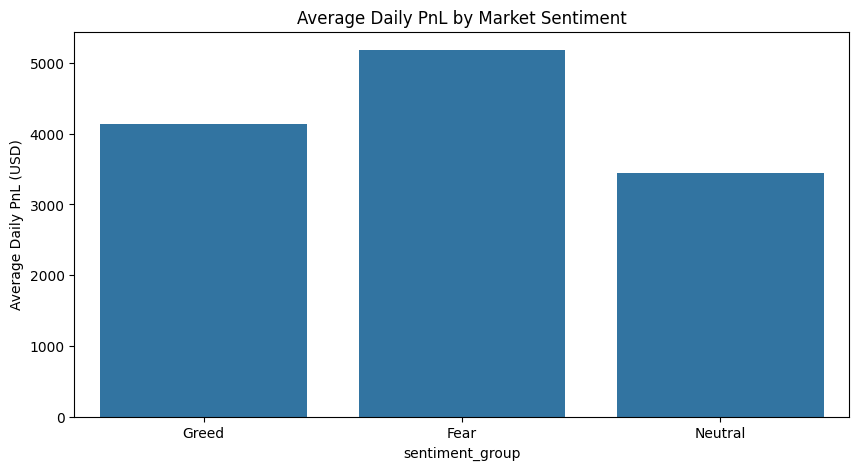

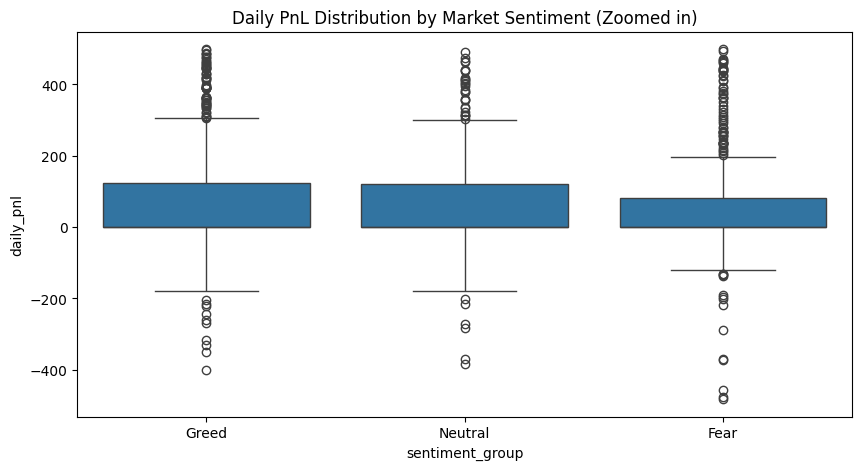

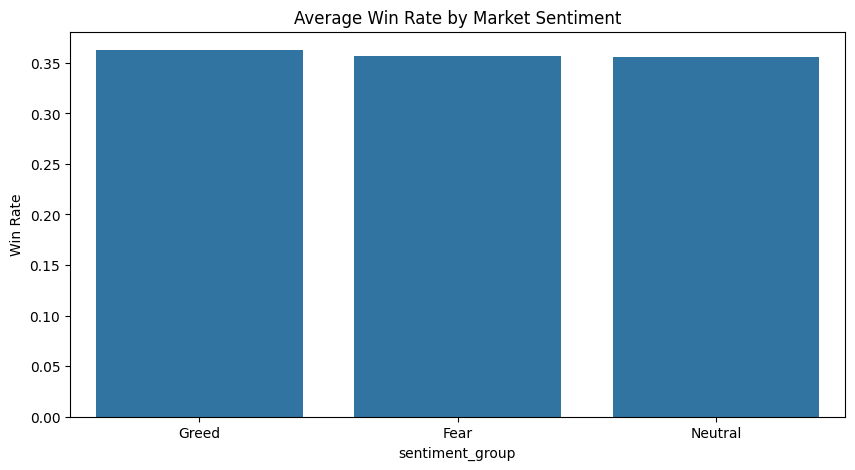

In [4]:
# Classify Fear vs Greed simply
daily_trader['sentiment_group'] = daily_trader['classification'].apply(
    lambda x: 'Fear' if 'Fear' in str(x) else ('Greed' if 'Greed' in str(x) else 'Neutral')
)

# 1. Performance differences
perf_summary = daily_trader.groupby('sentiment_group').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_count=('trade_count', 'mean')
).reset_index()

print("Performance by Sentiment Group:")
print(perf_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=daily_trader, x='sentiment_group', y='daily_pnl', ci=None)
plt.title("Average Daily PnL by Market Sentiment")
plt.ylabel("Average Daily PnL (USD)")
plt.savefig('pnl_by_sentiment.png')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=daily_trader[daily_trader['daily_pnl'].between(-500, 500)], x='sentiment_group', y='daily_pnl')
plt.title("Daily PnL Distribution by Market Sentiment (Zoomed in)")
plt.savefig('pnl_dist_sentiment.png')
plt.show()

# Win Rate
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_trader, x='sentiment_group', y='win_rate', ci=None)
plt.title("Average Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.savefig('winrate_by_sentiment.png')
plt.show()


Behavior by Sentiment:
  sentiment_group  avg_trade_size  avg_daily_volume  avg_long_short_ratio
0            Fear     8529.859802     756720.318013              8.378017
1           Greed     5954.632633     351829.352036              5.727530
2         Neutral     6963.694861     479367.189043              6.450631


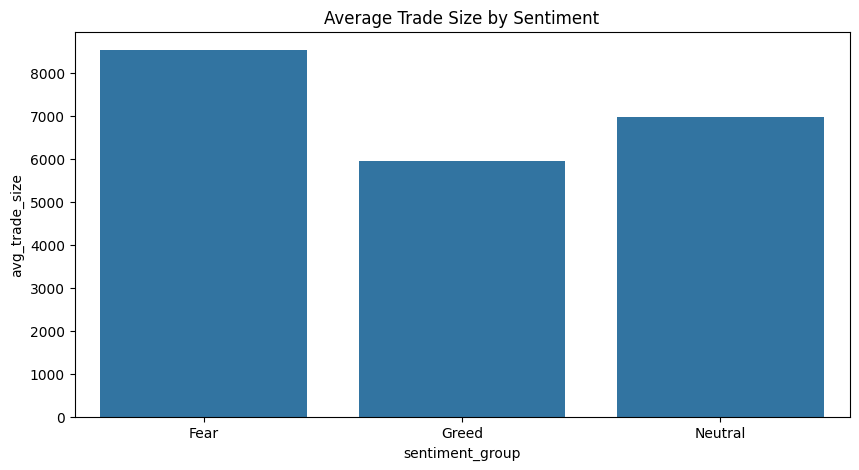

In [5]:
# 2. Behavior differences
behavior_summary = daily_trader.groupby('sentiment_group').agg(
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_daily_volume=('total_volume', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean')
).reset_index()

print("Behavior by Sentiment:")
print(behavior_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=behavior_summary, x='sentiment_group', y='avg_trade_size')
plt.title("Average Trade Size by Sentiment")
plt.savefig('trade_size_sentiment.png')
plt.show()


Traders segmented by Activity:
activity_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

Traders segmented by Performance:
performance_segment
Consistent Winner    16
Inconsistent         16
Name: count, dtype: int64


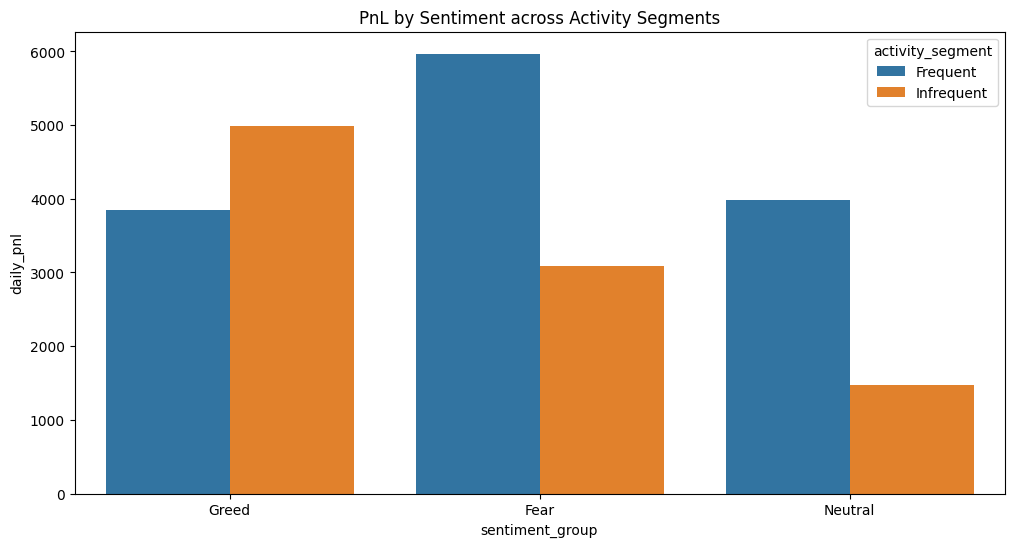

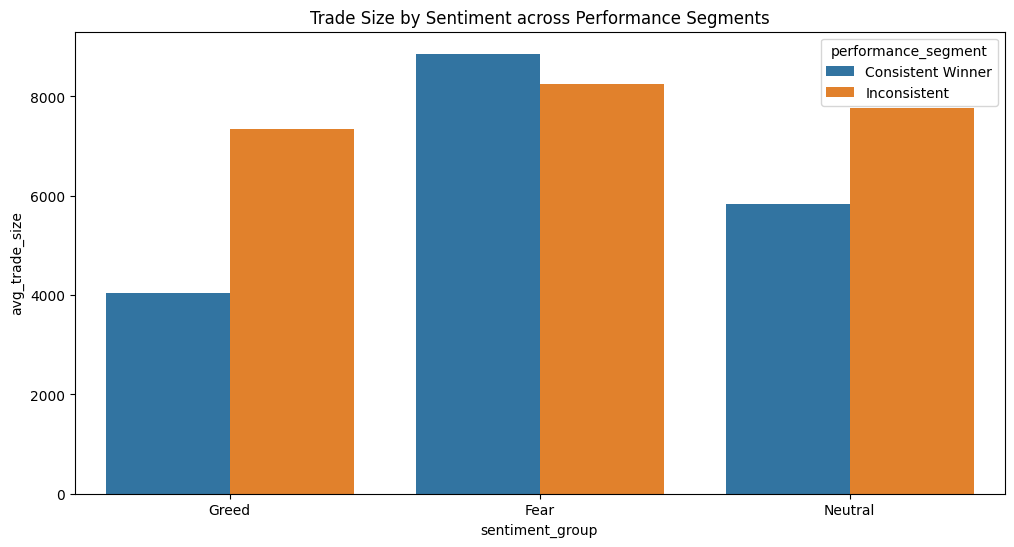

In [6]:
# 3. Segments of Traders
# We'll aggregate over the whole period for each account
trader_profiles = daily_trader.groupby('Account').agg(
    total_trades=('trade_count', 'sum'),
    win_rate_overall=('win_rate', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    total_pnl=('daily_pnl', 'sum'),
    avg_long_short_ratio=('long_short_ratio', 'mean')
).reset_index()

# Create Segments
# Segment 1: Frequent vs Infrequent Traders
median_trades = trader_profiles['total_trades'].median()
trader_profiles['activity_segment'] = ['Frequent' if x > median_trades else 'Infrequent' for x in trader_profiles['total_trades']]

# Segment 2: Consistent Winners vs Inconsistent
median_winrate = trader_profiles['win_rate_overall'].median()
trader_profiles['performance_segment'] = ['Consistent Winner' if x > median_winrate else 'Inconsistent' for x in trader_profiles['win_rate_overall']]

print("Traders segmented by Activity:")
print(trader_profiles['activity_segment'].value_counts())

print("\nTraders segmented by Performance:")
print(trader_profiles['performance_segment'].value_counts())

# Add segments back to daily tracking
daily_trader = daily_trader.merge(trader_profiles[['Account', 'activity_segment', 'performance_segment']], on='Account', how='left')

plt.figure(figsize=(12, 6))
sns.barplot(data=daily_trader, x='sentiment_group', y='daily_pnl', hue='activity_segment', ci=None)
plt.title("PnL by Sentiment across Activity Segments")
plt.savefig('pnl_sentiment_activity.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=daily_trader, x='sentiment_group', y='avg_trade_size', hue='performance_segment', ci=None)
plt.title("Trade Size by Sentiment across Performance Segments")
plt.savefig('tradesize_sentiment_performance.png')
plt.show()


## Part C - Actionable Output
**Hypotheses / Strategies:**
1. Given that Frequent traders may underperform during extreme fear days (if data suggests), scale back the frequency of trades for high-activity accounts during high Fear. 
2. Consistent winners might reduce trade sizes during 'Greed' to lock in profits or mitigate reversal risks. Wait for the data to confirm!
